In [102]:
import kagglehub
import pandas as pd
import glob, os

path = kagglehub.dataset_download("harshadapatil31/student-performance-and-study-habits-dataset")
csv_file = glob.glob(os.path.join(path, "*.csv"))[0]
df = pd.read_csv(csv_file)

df.info()

Using Colab cache for faster access to the 'student-performance-and-study-habits-dataset' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   objec

In [103]:
df.head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


In [104]:
df['final_grade'].value_counts()

,count
final_grade,
B,354
A,284
C,261
D,89
F,12


First of all, I want to be more specific about the `final_grade`.
I will engineer it for each single grade into 2 parts, the typical grade and the grade with the `+`,

Such as `A` & `A+`.

I will do it by usibg the `final_exam_score` feature, and after i'm done I will drop it.

In [105]:
def get_grade(final_exam_score):
  if 95 <= final_exam_score:
    return 'A+'
  elif 90 <= final_exam_score:
    return 'A'
  elif 85 <= final_exam_score:
    return 'B+'
  elif 80 <= final_exam_score:
    return 'B'
  elif 75 <= final_exam_score:
    return 'C+'
  elif 70 <= final_exam_score:
    return 'C'
  elif 65 <= final_exam_score:
    return 'D+'
  elif 60 <= final_exam_score:
    return 'D'
  elif 60 > final_exam_score:
    return 'F'
  else:
    print ("Something is wrong")

In [106]:
#df['final_grade'] = df['final_exam_score'].apply(get_grade)
#df['final_grade'].value_counts()

In [107]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [108]:
df = df.drop(columns=['final_exam_score', 'student_id'])
df.head()

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,A
3,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,D


In [109]:
df

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,A
3,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,D
...,...,...,...,...,...,...,...,...,...,...
995,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,C
996,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,A
997,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,C
998,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,B


Now, we fill the Na rows.

In [110]:
df['parental_education'].value_counts()

,count
parental_education,
High School,356
Bachelors,308
Masters,184
PhD,50


Because we don't have a dominant class on the `parental_education`,
we're gonna fill it with a new class that is `Unknown`.

In [111]:
df['parental_education'] = df['parental_education'].fillna('Unknown')
df.isna().sum()

,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,0
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0
final_grade,0


In [112]:
df.isna().sum()

,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,0
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0
final_grade,0


Now, we convert the categorical columns into embeddings so we can train the model

In [126]:
df['final_grade'].value_counts()

,count
final_grade,
B,354
A,284
C,261
D,89
F,12


In [114]:
import numpy as np
import sklearn as skl
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import LabelEncoder


X = df.drop(columns=['final_grade'])
y = df['final_grade']


numeric_cols = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']
cat_columns = ['parental_education']
bi_columns = ['gender', 'internet_access', 'extracurricular_activities', 'part_time_job']

X = pd.get_dummies(X, columns=cat_columns, drop_first=True)
encoder = LabelEncoder()

for col in bi_columns:
    X[col] = encoder.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    stratify=y)

In [146]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

std = StandardScaler()
X_train_scaled[numeric_cols] = std.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = std.transform(X_test[numeric_cols])

smote = SMOTE(sampling_strategy={'A': 750, 'B': 750, 'C': 750, 'D': 750, 'F': 150}, random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

In [147]:
X_train_resampled.shape

(3150, 12)

In [148]:
y_train_resampled.value_counts()

,count
final_grade,
A,750
D,750
B,750
C,750
F,150


In [138]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Random Forest Classifier': RandomForestClassifier()}

param_grids = {
    'Logistic Regression': [
        {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'saga']},
        {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
        {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8], 'solver': ['saga']}
    ],
    'Random Forest Classifier': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    }
}

In [149]:
skf = StratifiedKFold(5, shuffle=True, random_state=42)

best_models = {}
for name, model in models.items():
  grid = GridSearchCV(model, param_grids[name], cv=skf, scoring='f1_weighted')
  grid.fit(X_train_resampled, y_train_resampled)

  best_models[name] = grid.best_estimator_
  print(f'{name} model best score: {grid.best_score_}')
  print(f'{name} model best params: {grid.best_params_}')

Logistic Regression model best score: 0.621365228872946
Logistic Regression model best params: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Random Forest Classifier model best score: 0.9164008346488481
Random Forest Classifier model best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


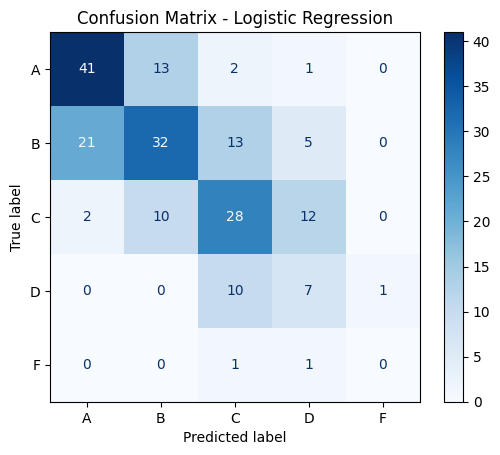

In [151]:
y_pred = best_models['Logistic Regression'].predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=best_models['Logistic Regression'].classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_models['Logistic Regression'].classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

now let's save our best model

In [152]:
import pickle

with open('best_rf_model.pkl', 'wb') as f: # Model
    pickle.dump(best_models['Random Forest Classifier'], f)

with open('scaler.pkl', 'wb') as f: # Scaler
    pickle.dump(std, f)

with open('X_columns.pkl', 'wb') as f: # Columns
    pickle.dump(X_train.columns.tolist(), f)

Gradio UI

In [161]:
for col in numeric_cols:
  print(f'Max value for {[col]} is: {df[col].max()}')
  print(f'Max value for {[col]} is: {df[col].min()}')

Max value for ['study_time_hours'] is: 8.1
Max value for ['study_time_hours'] is: 0.5
Max value for ['attendance_percent'] is: 100.0
Max value for ['attendance_percent'] is: 54.8
Max value for ['sleep_hours'] is: 10.0
Max value for ['sleep_hours'] is: 3.2
Max value for ['previous_grade'] is: 100.0
Max value for ['previous_grade'] is: 31.3


In [164]:
!pip install --upgrade gradio -q

In [171]:
with open('best_rf_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('X_columns.pkl', 'rb') as f:
    expected_columns = pickle.load(f)

numeric_cols = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']

def predict_grade(gender, study_time_hours, attendance_percent, sleep_hours,
                   parental_education, internet_access, extracurricular_activities,
                   part_time_job, previous_grade):
    input_dict = {
        'gender': 1 if gender == 'Male' else 0,
        'study_time_hours': study_time_hours,
        'attendance_percent': attendance_percent,
        'sleep_hours': sleep_hours,
        'internet_access': 1 if internet_access == 'Yes' else 0,
        'extracurricular_activities': 1 if extracurricular_activities == 'Yes' else 0,
        'part_time_job': 1 if part_time_job == 'Yes' else 0,
        'previous_grade': previous_grade,
    }
    for col in expected_columns:
        if col.startswith('parental_education_'):
            input_dict[col] = 1 if col == f'parental_education_{parental_education}' else 0

    input_df = pd.DataFrame([input_dict]).reindex(columns=expected_columns, fill_value=0)
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    prediction = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    confidence = max(proba) * 100
    return f"Predicted Grade: {prediction}   |   Confidence: {confidence:.1f}%"

with gr.Blocks(theme=gr.themes.Default(), title="Student Grade Predictor") as demo:
    gr.Markdown("# Student Grade Predictor")
    gr.Markdown("Predicts a student's final grade (A–F) from study habits and background factors using a Random Forest classifier.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Academic")
            study_time_hours = gr.Slider(0.5, 8.0, value=3.0, step=0.1, label="Study Time (hours/day)")
            attendance_percent = gr.Slider(55.0, 100.0, value=85.0, step=0.1, label="Attendance (%)")
            previous_grade = gr.Slider(33.33, 100.0, value=75.0, step=0.1, label="Previous Grade Score")

        with gr.Column():
            gr.Markdown("### Lifestyle")
            sleep_hours = gr.Slider(3.2, 10.0, value=7.0, step=0.1, label="Sleep Hours")
            internet_access = gr.Radio(['Yes', 'No'], label="Internet Access", value='Yes')
            extracurricular_activities = gr.Radio(['Yes', 'No'], label="Extracurricular Activities", value='No')
            part_time_job = gr.Radio(['Yes', 'No'], label="Part-time Job", value='No')

        with gr.Column():
            gr.Markdown("### Background")
            gender = gr.Radio(['Male', 'Female'], label="Gender", value='Male')
            parental_education = gr.Dropdown(
                ['High School', 'Bachelors', 'Masters', 'PhD', 'Unknown'],
                label="Parental Education", value='Bachelors'
            )

    predict_btn = gr.Button("Predict Grade", variant="primary", size="lg")
    output = gr.Textbox(label="Result", lines=1)

    predict_btn.click(
        fn=predict_grade,
        inputs=[gender, study_time_hours, attendance_percent, sleep_hours,
                parental_education, internet_access, extracurricular_activities,
                part_time_job, previous_grade],
        outputs=output
    )

demo.launch(share=True)

/tmp/ipykernel_1910/69404558.py:35: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Default(), title="Student Grade Predictor") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dc49509addbe9650a2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Approach:

### 1.0 - EDA
First, I loaded the data and took a look, I realized that we have two goal columns, `final_exam_score` & `final_grade`.

Since we want our problem to be **Classification**, what we're going to predict is going to be the `final_grade` column because it has multiple classes; A, B, C, D and F.

### 2.0 - Feature Engineering
After that conclusion I decided to engineer our `final_grade` column to be more precise, so each grade now is separated into two grades (except the F grade, it remains the same), the regular grade and the grade with `+`, the way I separated them is by using the `final_exam_score` and applying it to the `get_grade(exam_score)` function which checks if the score meets certain conditions to get the final grade (with the + or without).

We had 5 classes but after what we've done, now we have 9 (A+, A, B+, B, C+, C, D+, D, F).

### 3.0 - Pre-Processing
Now we move to the pre-processing part.

### 3.1 - Filling missing data
The data has some missing values in the `parental_education` column, and we do not have a dominant Mode to fill the data with, and the data is so little that I can't drop any samples and waste them; I created a new class named `Unknown` and filled the missing values in that column with it.

It contained two sections (Embedding & Standardization).
First of all, I created 3 lists:

- First list for the categorical (string) columns (e.g. `parental_education`).

- Second list of the binary columns (e.g. `gender`) that are either 0 or 1.

- Third list of the numerical columns (e.g. `sleep_hours`).

### 3.2 - Embedding
- Binary columns: I embedded the binary columns (e.g. `Yes` & `No` to `0` & `1`) using `LabelEncoder()`.

- Categorical columns: I embedded them using the built-in pandas function `get_dummies`.

### 3.3 - Standardization
- Numerical columns: They don't need embedding (clearly because they're already numerical), but they DO NEED some work — I applied `StandardScaler()` to scale them all around 0 so larger values do not dominate the smaller ones.

### 4.0 - Models Training
After everything we've done, now we're ready to get our hands on the model. I trained the model on the new embedded & scaled split, but it wasn't a regular training — I used `GridSearchCV` with some parameters for each of my two models, `Logistic Regression` and `Random Forest Classifier`.

### 4.1 - GridSearchCV & StratifiedKFold
I used `StratifiedKFold()` to split my training data into 5 parts.

### 5.0 - Poor scoring on evaluation (imbalanced classes)
Because of my feature engineering on the goal column, it divided into smaller parts (5 → 9), and my data was already too small, so there wasn't a lot of data and the model was overfitting. So I just reversed my feature engineering on the goal column to what it was before my processing (9 → 5), but even that wasn't enough because the dataset is still too small, being only 1000 samples.

- Logistic Regression F1 score: ~53%
- Random Forest Classifier F1 score: ~49%

### 6.0 - Synthetic Data
I created many more samples myself using the `K-NN` algorithm via `SMOTE`, resulting in **3150** samples in training instead of only **800**.
Now we cover all the rare classes like the `F` class, which we only had **12** samples of, but after our resampling now we have **150** of it, so we can give our models some space to learn the patterns, and now we've fixed the class imbalancing.

### 7.0 - Re-train models & Re-evaluate them
After all we've been through, now we retrain the models and test them on our new, much larger data, and it wasn't a surprise that the scores went up significantly, but our `LogisticRegression()` model still isn't doing very well, even though it improved.
- Logistic Regression F1 score: ~62%
- Random Forest Classifier F1 score: ~92%

Of course the `RandomForestClassifier()` had a big jump because its algorithm is very "thirsty" for data and it performs very well on larger datasets.

### 8.0 - Save the model
We need to save the model so we can use it in Gradio for the next phase; I used `pickle` to save the model.
> Note: I saved my best model, which is the `RandomForestClassifier()`.

### 9.0 - Gradio User Interface (UI)
I used `Gradio` for the UI, and my model is `RandomForestClassifier()` since it outperformed `LogisticRegression()`.